# **EDA & Final Feature Selection**

**Project**: Airbnb Market Segmentation Analysis

**Goal**: Explore the final feature set as a whole, treating it as one unified landscape. This notebook has two main purposes:
- surface the market's actual geographic and structural shape
- produce the final feature short-list that carries into modeling.

## 1. Setup & Data Landscape

### 1.1 Imports & Environment

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import re
import html

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
# Base path configuration
BASE_PATH = Path.cwd().parent

### 1.2 Data Loading

In [3]:
listings = pd.read_csv(BASE_PATH / 'data' / 'processed' / 'listings_nlp.csv')
reviews = pd.read_csv(BASE_PATH / 'data' / 'processed' / 'reviews_nlp.csv')

/var/folders/s_/9j10gw751dgb6tbppsps9d7w0000gn/T/ipykernel_21541/1400831209.py:2: DtypeWarning: Columns (0: review_dominant_topic) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews = pd.read_csv(BASE_PATH / 'data' / 'processed' / 'reviews_nlp.csv')


In [10]:
if listings.columns[0].startswith('Unnamed'):
    listings = listings.drop(columns=[listings.columns[0]])

print(f"listings: {listings.shape[0]:,} rows x {listings.shape[1]} columns")
print(f"\ndtypes:\n{listings.dtypes.value_counts()}")

listings: 35,818 rows x 206 columns

dtypes:
float64    124
str         48
int64       34
Name: count, dtype: int64


In [11]:
if reviews.columns[0].startswith('Unnamed'):
    reviews = reviews.drop(columns=[reviews.columns[0]])

print(f"reviews: {reviews.shape[0]:,} rows x {reviews.shape[1]} columns")
print(f"\ndtypes:\n{reviews.dtypes.value_counts()}")

reviews: 604,821 rows x 9 columns

dtypes:
str        5
int64      2
float64    1
bool       1
Name: count, dtype: int64


In [8]:
neighbourhoods = gpd.read_file(BASE_PATH / 'data' / 'raw' / 'neighbourhoods.geojson')
print(f"neighbourhood boundaries: {len(neighbourhoods)} polygons")
print(f"columns: {list(neighbourhoods.columns)}")
neighbourhoods.head(5)

neighbourhood boundaries: 15 polygons
columns: ['neighbourhood', 'neighbourhood_group', 'geometry']


,neighbourhood,neighbourhood_group,geometry
0,I Centro Storico,None,"MULTIPOLYGON (((12.44396 41.9339, 12.44472 41...."
1,III Monte Sacro,None,"MULTIPOLYGON (((12.56321 42.07464, 12.5627 42...."
2,IV Tiburtina,None,"MULTIPOLYGON (((12.63542 41.95729, 12.63696 41..."
3,VI Roma delle Torri,None,"MULTIPOLYGON (((12.70671 41.93374, 12.70691 41..."
4,VII San Giovanni/Cinecittà,None,"MULTIPOLYGON (((12.51668 41.89194, 12.52266 41..."


In [14]:
listing_neighbourhoods = set(listings['neighbourhood_cleansed'].dropna().unique())
geojson_neighbourhoods = set(neighbourhoods['neighbourhood'].unique())

print(f"listings: {len(listing_neighbourhoods)} distinct neighbourhoods")
print(f"geojson: {len(geojson_neighbourhoods)} distinct neighbourhoods")
print(f"\nin listings but not geojson: {listing_neighbourhoods - geojson_neighbourhoods}")
print(f"in geojson but not listings: {geojson_neighbourhoods - listing_neighbourhoods}")

listings: 15 distinct neighbourhoods
geojson: 15 distinct neighbourhoods

in listings but not geojson: set()
in geojson but not listings: set()


In [15]:
# consistent visual style for every figure in this notebook
plt.rcParams.update({
    'figure.dpi': 150,           # on-screen rendering
    'savefig.dpi': 300,          # print-quality export
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linewidth': 0.5,
    'figure.facecolor': 'white',
    'savefig.facecolor': 'white',
    'savefig.bbox': 'tight',
})

# a small palette reused throughout
ROME_PALETTE = {
    'primary': '#8B3A3A',      # terracotta/brick
    'secondary': '#4C6B8A',    # muted blue, for contrast/comparison series
    'accent': '#C9A227',       # ochre, for highlights/call-outs
    'neutral': '#6B6B6B',      # grey, for de-emphasized reference lines
    'light_bg': '#F5F1EC',     # warm off-white, for map/plot backgrounds
}
sns.set_palette([ROME_PALETTE['primary'], ROME_PALETTE['secondary'], ROME_PALETTE['accent']])

## 2. Market Overview

This section establishes the market's basic shape and scale in one glance: how big is it, what does a typical listing cost, and what are people actually renting.

### 2.1 Market Scale & Scope

In [16]:
scale_summary = pd.DataFrame({
    'metric': [
        'Total listings', 'Unique hosts', 'Listings per host (avg)',
        'Municipi (districts)', 'Property types (grouped)',
        'Price range (€)', 'Median price (€)',
    ],
    'value': [
        f"{listings['id'].nunique():,}",
        f"{listings['host_id'].nunique():,}",
        f"{listings['id'].nunique() / listings['host_id'].nunique():.2f}",
        f"{listings['neighbourhood_cleansed'].nunique()}",
        f"{listings['property_type_grouped'].nunique()}",
        f"{listings['price'].min():.0f} – {listings['price'].max():.0f}",
        f"{listings['price'].median():.0f}",
    ]
})
display(scale_summary)

,metric,value
0,Total listings,"35,818"
1,Unique hosts,"20,010"
2,Listings per host (avg),1.79
3,Municipi (districts),15
4,Property types (grouped),6
5,Price range (€),8 – 1005
6,Median price (€),131


35,818 listings across 20,010 hosts (1.79 listings/host on average) span all 15 municipi of Rome, with prices ranging €8-1,005 and a median of €131.

### 2.2 Price

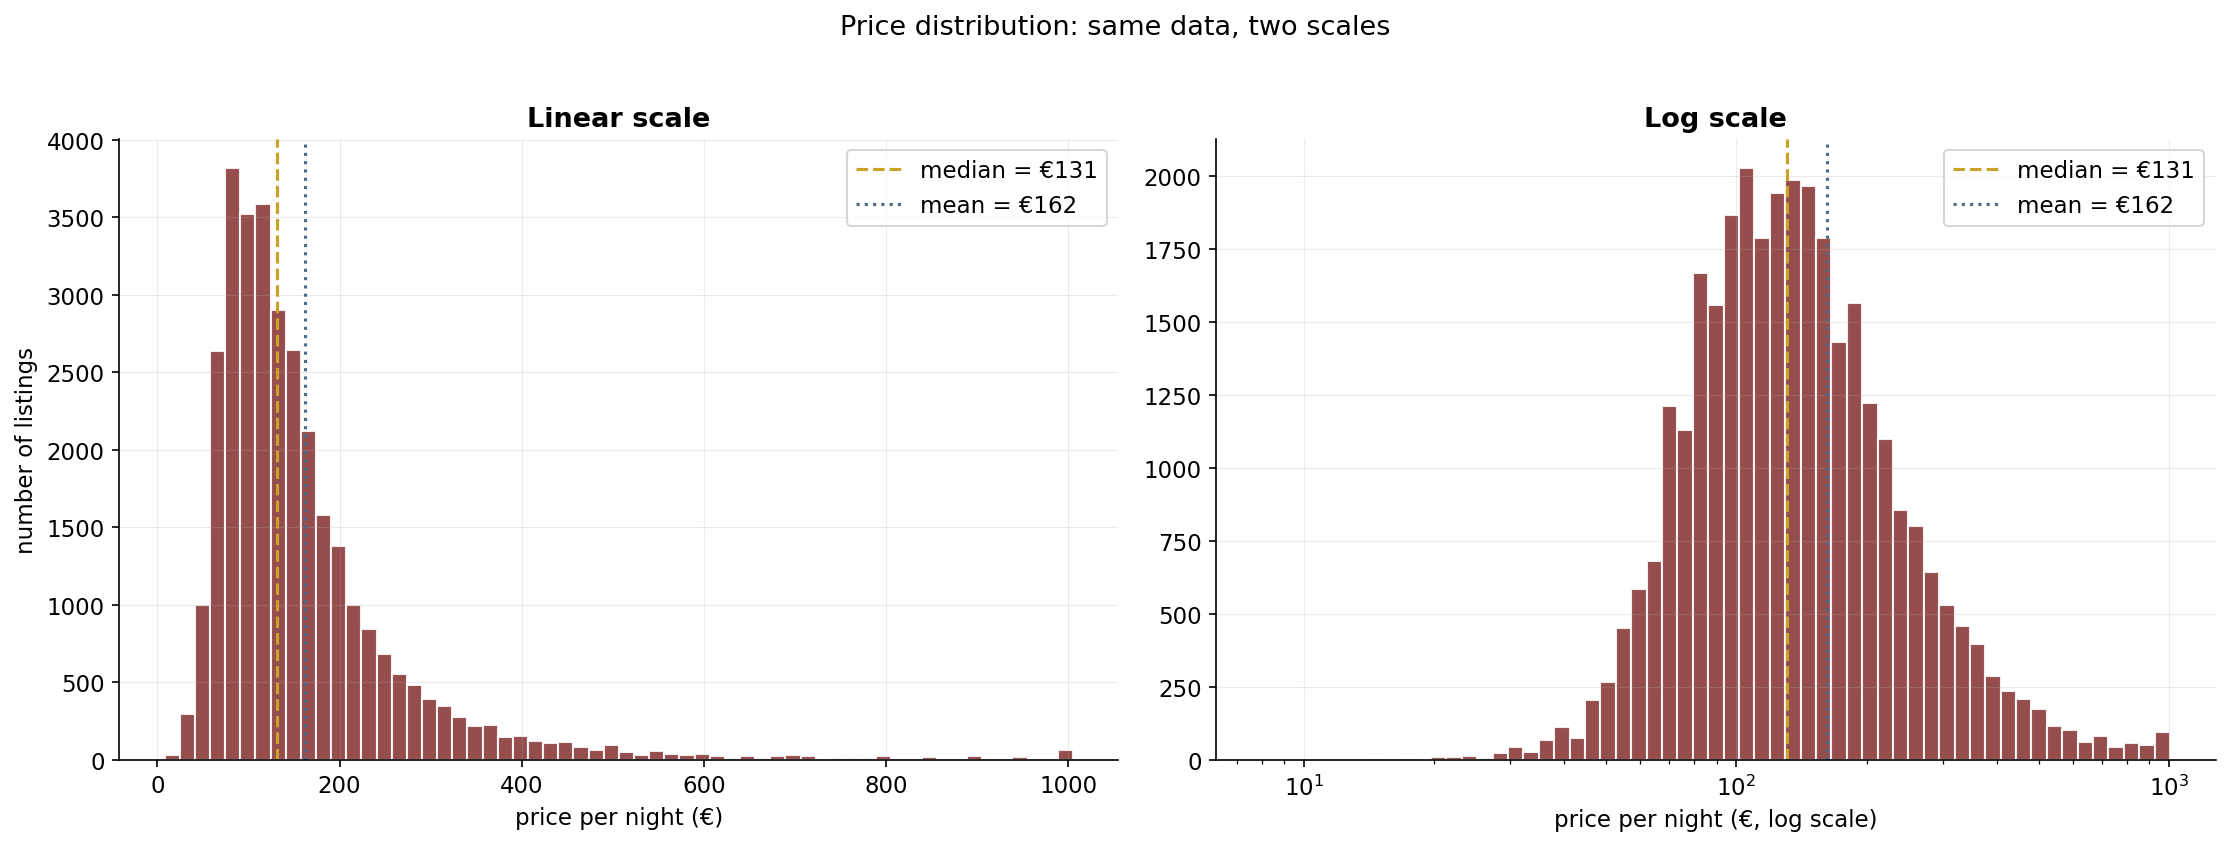

In [19]:
price_data = listings['price'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# left: raw shape
axes[0].hist(price_data, bins=60, color=ROME_PALETTE['primary'], edgecolor='white', alpha=0.9)
axes[0].axvline(price_data.median(), color=ROME_PALETTE['accent'], linestyle='--', linewidth=1.5,
                 label=f"median = €{price_data.median():.0f}")
axes[0].axvline(price_data.mean(), color=ROME_PALETTE['secondary'], linestyle=':', linewidth=1.5,
                 label=f"mean = €{price_data.mean():.0f}")
axes[0].set_xlabel('price per night (€)')
axes[0].set_ylabel('number of listings')
axes[0].set_title('Linear scale')
axes[0].legend()

# right: log scale
log_bins = np.logspace(np.log10(price_data.min()), np.log10(price_data.max()), 60)
axes[1].hist(price_data, bins=log_bins, color=ROME_PALETTE['primary'], edgecolor='white', alpha=0.9)
axes[1].set_xscale('log')
axes[1].axvline(price_data.median(), color=ROME_PALETTE['accent'], linestyle='--', linewidth=1.5,
                 label=f"median = €{price_data.median():.0f}")
axes[1].axvline(price_data.mean(), color=ROME_PALETTE['secondary'], linestyle=':', linewidth=1.5,
                 label=f"mean = €{price_data.mean():.0f}")
axes[1].set_xlabel('price per night (€, log scale)')
axes[1].set_title('Log scale')
axes[1].legend()

plt.suptitle('Price distribution: same data, two scales', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

The gap between mean (€162) and median (€131) signals the right-skew visible in the histogram. The log-scale x-axis turns what would otherwise be a single dominant spike near zero into a clear, roughly symmetric bell around €70-100, confirming this is the natural scale for `price` in any downstream modeling.

Price is missing for 10.4% of listings. It is a gap traced back to the original scrape, unrelated to any text-coverage limitation documented in the NLP notebook. All price-based figures in this notebook use the 32,081 listings with a recorded value.

### 2.3 Price Tiers & Distribution Shape

/var/folders/s_/9j10gw751dgb6tbppsps9d7w0000gn/T/ipykernel_21541/1588021694.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  listings['price_tier'] = listings['price'].apply(assign_price_tier)


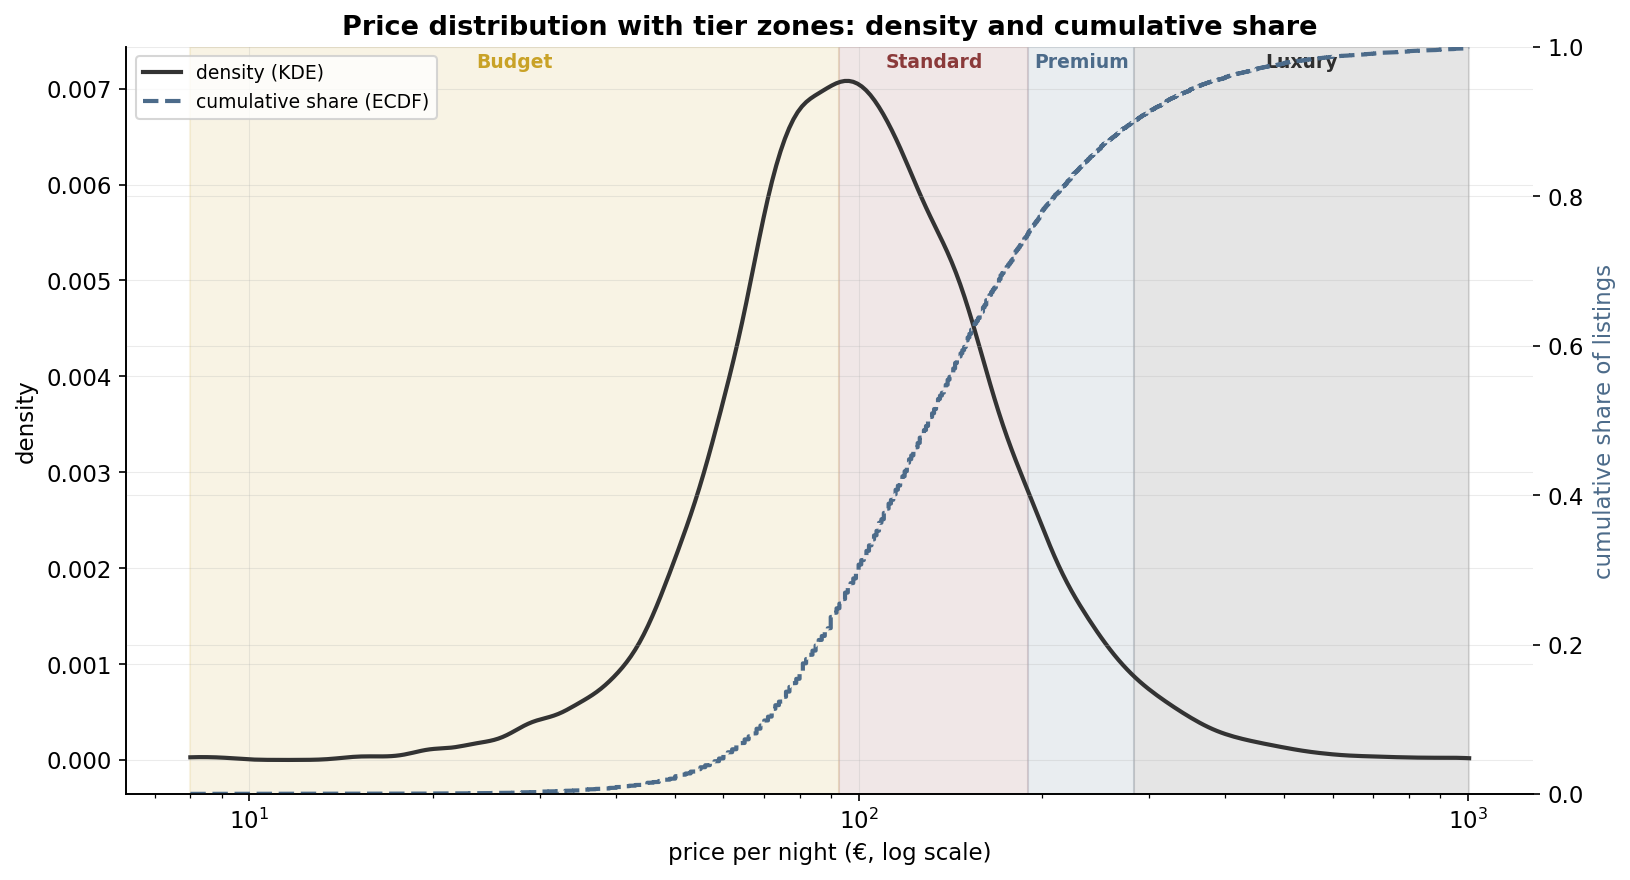

,count,pct,price_range (€)
price_tier,,,
Budget,7970,24.8,8–93
Standard,16051,50.0,93–190
Premium,4833,15.1,190–283
Luxury,3227,10.1,283–1005


In [21]:
from scipy.stats import gaussian_kde

q25, q75, q90 = price_data.quantile([0.25, 0.75, 0.90]).values
TIER_BOUNDS = [price_data.min(), q25, q75, q90, price_data.max()]
TIER_NAMES = ['Budget', 'Standard', 'Premium', 'Luxury']
TIER_COLORS = {'Budget': ROME_PALETTE['accent'], 'Standard': ROME_PALETTE['primary'],
               'Premium': ROME_PALETTE['secondary'], 'Luxury': '#2E2E2E'}

def assign_price_tier(p):
    if pd.isna(p):
        return np.nan
    if p < q25: return 'Budget'
    if p < q75: return 'Standard'
    if p < q90: return 'Premium'
    return 'Luxury'

listings['price_tier'] = listings['price'].apply(assign_price_tier)

fig, ax1 = plt.subplots(figsize=(11, 6))

log_price = np.log10(price_data)
kde = gaussian_kde(log_price)
x_grid = np.linspace(log_price.min(), log_price.max(), 300)
kde_vals = kde(x_grid) / (10**x_grid * np.log(10))

for i, name in enumerate(TIER_NAMES):
    ax1.axvspan(TIER_BOUNDS[i], TIER_BOUNDS[i+1], color=TIER_COLORS[name], alpha=0.12)
    mid = np.sqrt(TIER_BOUNDS[i] * TIER_BOUNDS[i+1])
    ax1.text(mid, kde_vals.max()*1.02, name, ha='center', fontsize=9, fontweight='bold', color=TIER_COLORS[name])

ax1.plot(10**x_grid, kde_vals, color='#333333', linewidth=2, label='density (KDE)')
ax1.set_xscale('log')
ax1.set_xlabel('price per night (€, log scale)')
ax1.set_ylabel('density')

ax2 = ax1.twinx()
sorted_price = np.sort(price_data)
ecdf_y = np.arange(1, len(sorted_price)+1) / len(sorted_price)
ax2.plot(sorted_price, ecdf_y, color=ROME_PALETTE['secondary'], linewidth=2, linestyle='--', label='cumulative share (ECDF)')
ax2.set_ylabel('cumulative share of listings', color=ROME_PALETTE['secondary'])
ax2.set_ylim(0, 1)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
ax1.set_title('Price distribution with tier zones: density and cumulative share')
plt.tight_layout()
plt.show()

tier_table = pd.DataFrame({
    'count': listings['price_tier'].value_counts().reindex(TIER_NAMES),
    'pct': listings['price_tier'].value_counts(normalize=True).mul(100).round(1).reindex(TIER_NAMES),
    'price_range (€)': [f"{TIER_BOUNDS[i]:.0f}–{TIER_BOUNDS[i+1]:.0f}" for i in range(4)],
})
display(tier_table)

The KDE peaks inside the Standard tier (€93-190), confirming this tier isn't an arbitrary quartile split but genuinely tracks where the market's mass sits, as half of all listings fall here, and it's visibly the single most crowded price zone on the chart. The ECDF's steepest climb happens across Budget→Standard, meaning small price movements in that range shift a large share of the market. By contrast, the flat ECDF tail through Premium and especially Luxury shows those tiers cover a huge price range (€283-1,005) for comparatively few listings, meaning the market thins out fast once prices climb past the median.

### 2.4 What Are People Renting?

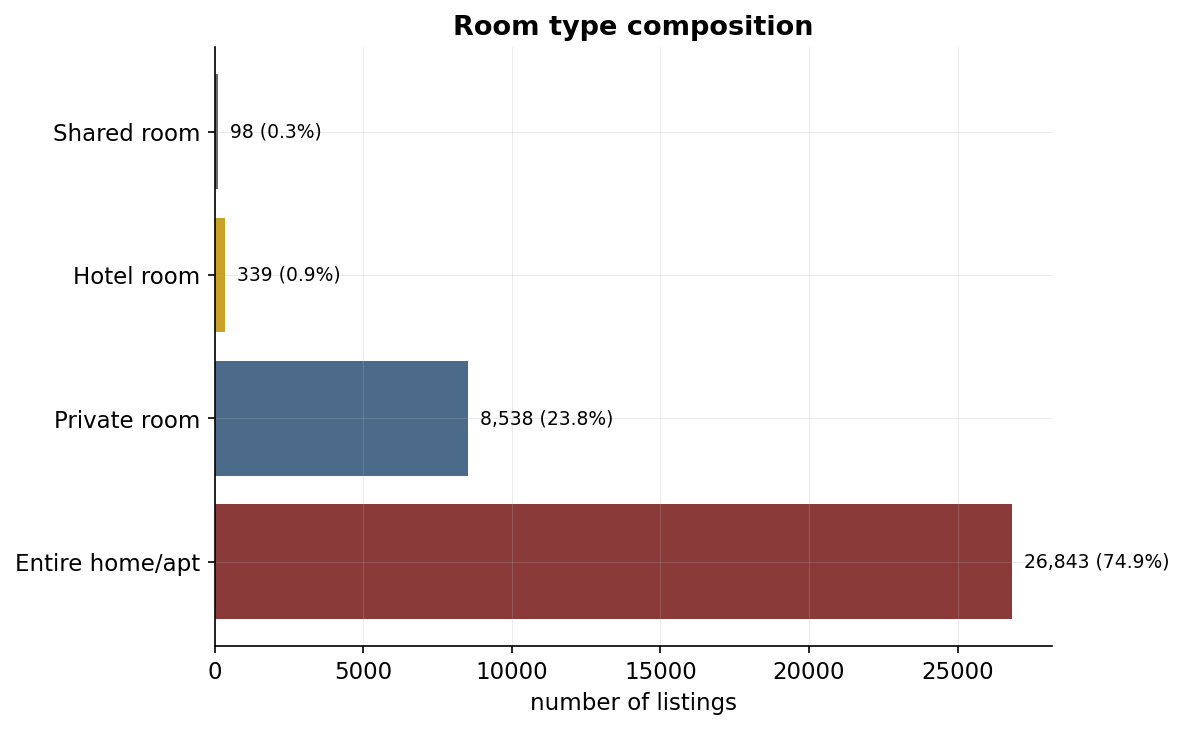

,count,pct
room_type,,
Entire home/apt,26843,74.9
Private room,8538,23.8
Hotel room,339,0.9
Shared room,98,0.3


In [ ]:
room_type_counts = listings['room_type'].value_counts()
room_type_pct = listings['room_type'].value_counts(normalize=True).mul(100).round(1)

fig, ax = plt.subplots(figsize=(8, 5))
colors = [ROME_PALETTE['primary'], ROME_PALETTE['secondary'], ROME_PALETTE['accent'], ROME_PALETTE['neutral']]
ax.barh(room_type_counts.index, room_type_counts.values, color=colors[:len(room_type_counts)])
for i, (count, pct) in enumerate(zip(room_type_counts.values, room_type_pct.values)):
    ax.text(count, i, f'  {count:,} ({pct}%)', va='center', fontsize=9)
ax.set_xlabel('number of listings')
ax.set_title('Room type composition')
plt.tight_layout()
plt.show()

room_type_table = pd.DataFrame({'count': room_type_counts, 'pct': room_type_pct})
display(room_type_table)

The market is overwhelmingly `Entire home/apt` (74.9%), so it is a market of whole-unit rentals, not shared accommodation. `Private room` is a real but distinctly secondary segment (23.8%), while `Hotel room` and `Shared room` combined barely register (1.2%).

### 2.5 Property Type & Size

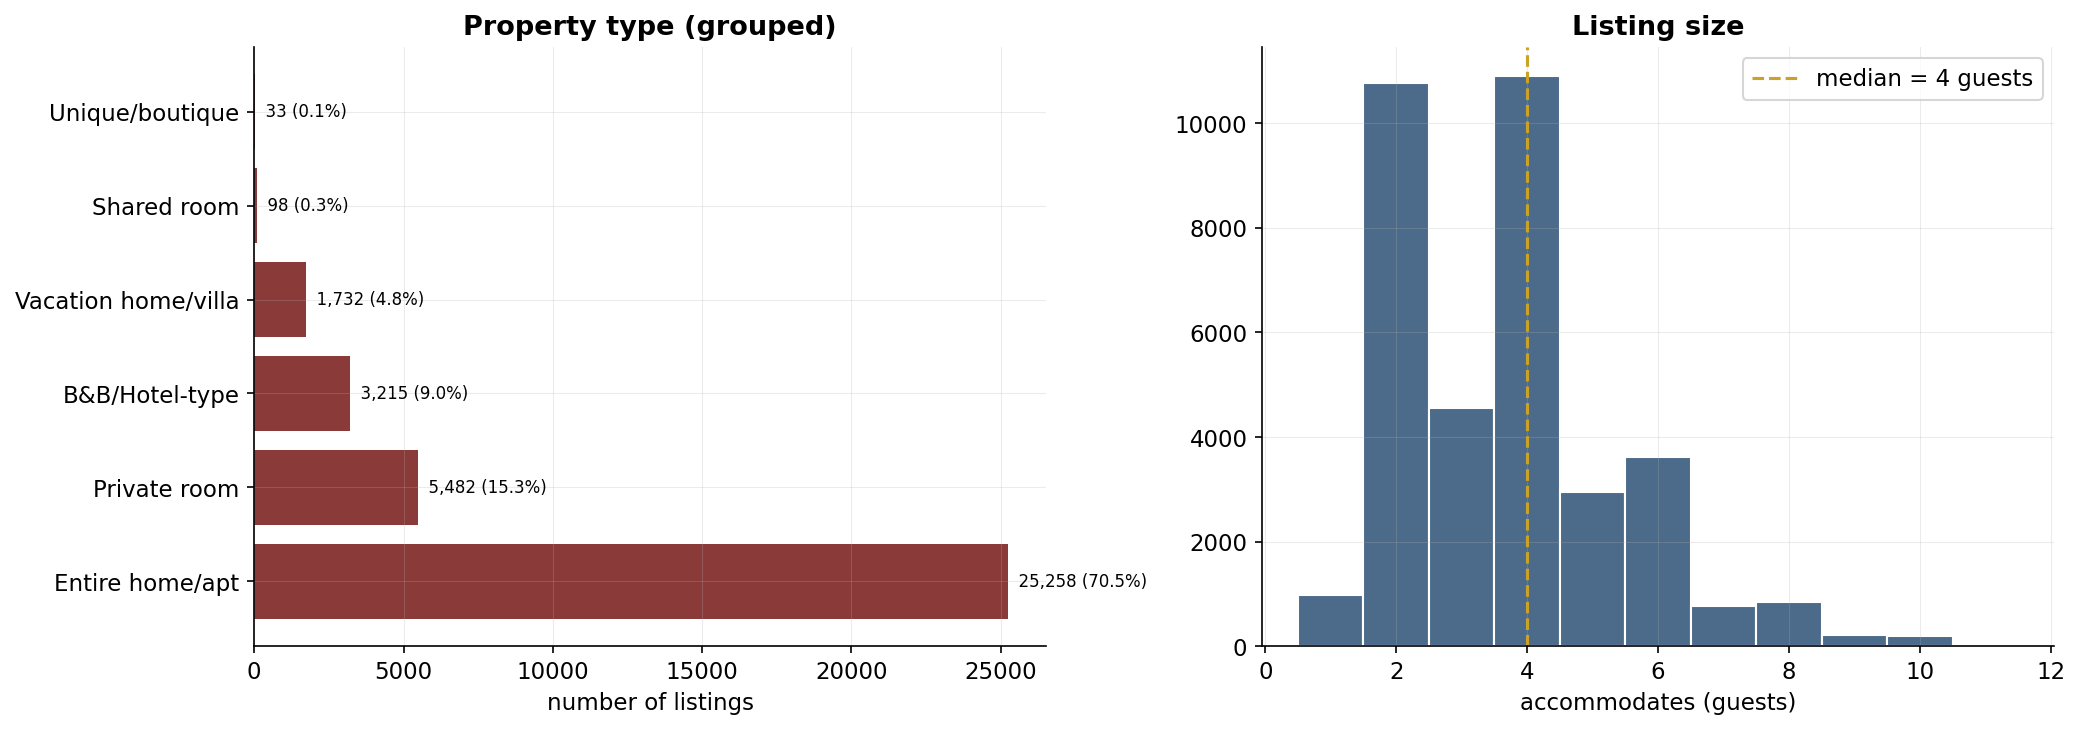

,count,pct
property_type_grouped,,
Entire home/apt,25258,70.5
Private room,5482,15.3
B&B/Hotel-type,3215,9.0
Vacation home/villa,1732,4.8
Shared room,98,0.3
Unique/boutique,33,0.1


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

prop_counts = listings['property_type_grouped'].value_counts()
prop_pct = listings['property_type_grouped'].value_counts(normalize=True).mul(100).round(1)
axes[0].barh(prop_counts.index, prop_counts.values, color=ROME_PALETTE['primary'])
for i, (count, pct) in enumerate(zip(prop_counts.values, prop_pct.values)):
    axes[0].text(count, i, f'  {count:,} ({pct}%)', va='center', fontsize=8)
axes[0].set_xlabel('number of listings')
axes[0].set_title('Property type (grouped)')

accommodates_data = listings['accommodates'].dropna()
axes[1].hist(accommodates_data, bins=range(1, int(accommodates_data.max())+2), align='left',
             color=ROME_PALETTE['secondary'], edgecolor='white')
axes[1].axvline(accommodates_data.median(), color=ROME_PALETTE['accent'], linestyle='--', linewidth=1.5,
                 label=f"median = {accommodates_data.median():.0f} guests")
axes[1].set_xlabel('accommodates (guests)')
axes[1].set_title('Listing size')
axes[1].legend()

plt.tight_layout()
plt.show()

prop_table = pd.DataFrame({'count': prop_counts, 'pct': prop_pct})
display(prop_table)

`property_type_grouped` tells a richer story than `room_type` alone: within the 74.9% "Entire home/apt" room-type share, a full third actually splits into more specific building types once `property_type_grouped` is applied. `B&B/Hotel-type` (9.0%) and `Vacation home/villa` (4.8%) both count as "entire place" under `room_type` but represent structurally distinct offerings.

Listing size clusters tightly around small-to-mid units: median 4 guests, with a sharp mode at 2 and a visible secondary bump at 4, consistent with a market built for couples and small families.

### 2.6 Price per Person vs. Capacity

/var/folders/s_/9j10gw751dgb6tbppsps9d7w0000gn/T/ipykernel_21541/174569037.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  listings['price_per_person'] = listings['price'] / listings['accommodates']


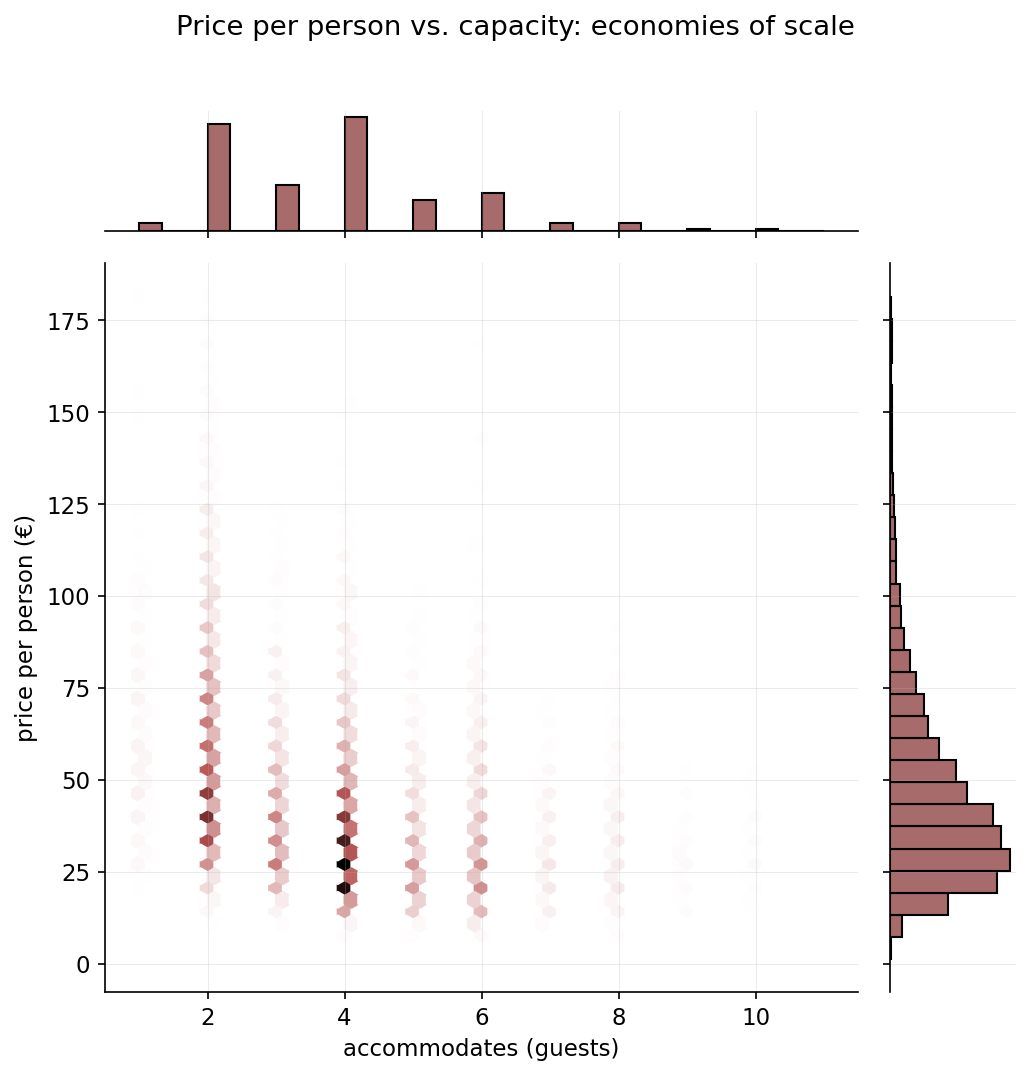

,median €/person
accommodates,
1,62.0
2,53.0
3,39.2
4,33.5
5,30.4
6,31.2
7,30.9
8,33.9
9,30.9


In [22]:
listings['price_per_person'] = listings['price'] / listings['accommodates']

joint_data = listings.dropna(subset=['price_per_person', 'accommodates']).copy()
joint_data = joint_data[joint_data['price_per_person'] <= joint_data['price_per_person'].quantile(0.99)]

g = sns.jointplot(data=joint_data, x='accommodates', y='price_per_person', kind='hex',
                   color=ROME_PALETTE['primary'], height=7,
                   marginal_kws=dict(bins=30, color=ROME_PALETTE['primary']))
g.ax_joint.set_xlabel('accommodates (guests)')
g.ax_joint.set_ylabel('price per person (€)')
g.fig.suptitle('Price per person vs. capacity: economies of scale', y=1.02)
plt.tight_layout()
plt.show()

display(joint_data.groupby('accommodates')['price_per_person'].median().round(1).to_frame('median €/person'))

The darkest hexbins sit at `accommodates=2` (€40-55/person) and `accommodates=4` (€25-35/person), which are the market's two dominant configurations. The median table confirms the economy-of-scale hypothesis directly: price per person drops steeply from €62 (solo travelers) to roughly €30-33 by accommodates=4-5, then flattens, meaning beyond 4 guests, adding capacity barely changes the per-person cost. This means that a solo traveler and a family of four are paying structurally different rates for the same underlying unit type.

### 2.7 Bed Capacity Concentration

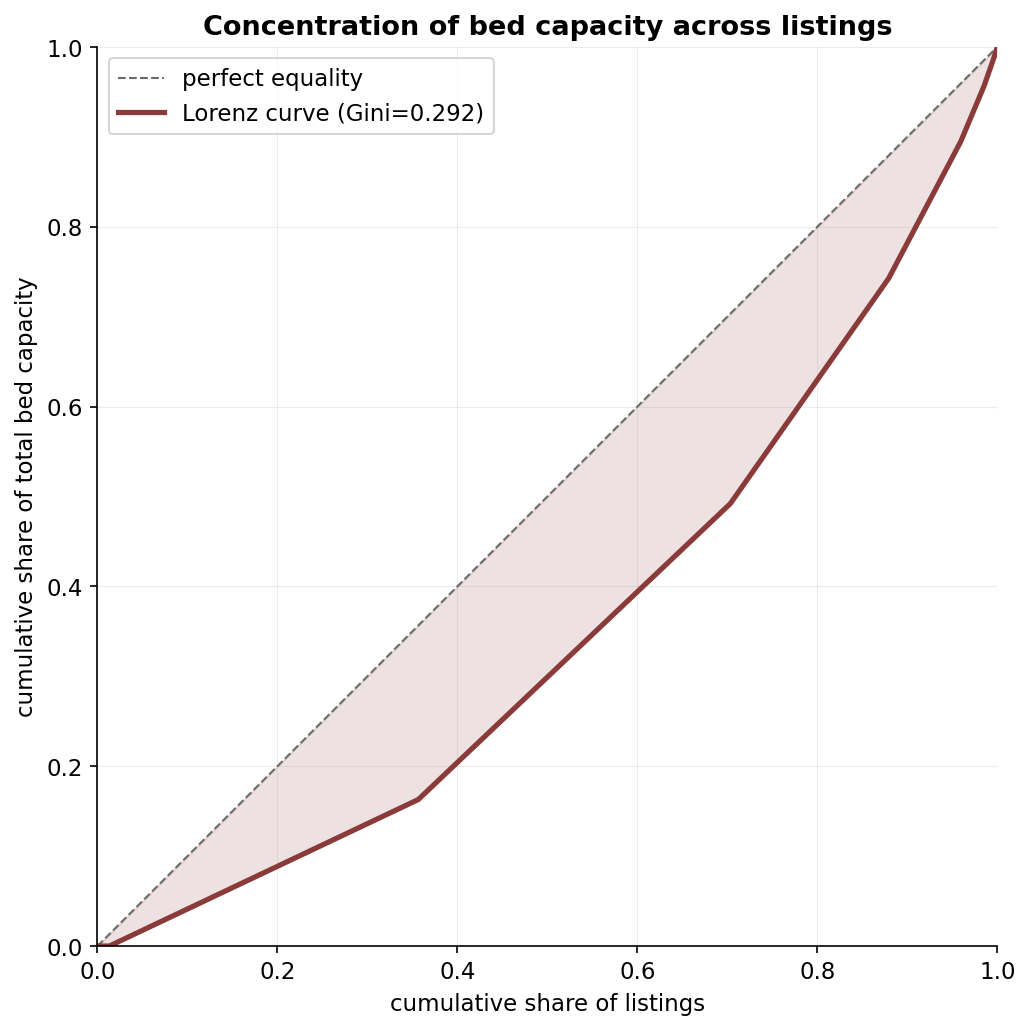

Gini coefficient: 0.292
bottom 50% of listings hold 29.9% of total bed capacity
top 10% of listings hold 21.8% of total bed capacity


In [26]:
listings['beds_restored'] = np.expm1(listings['beds_log'])
beds_sorted = listings['beds_restored'].dropna().sort_values().values
n = len(beds_sorted)
cum_listings_pct = np.arange(1, n+1) / n
cum_beds_pct = np.cumsum(beds_sorted) / beds_sorted.sum()
gini = 1 - 2 * np.trapezoid(cum_beds_pct, cum_listings_pct)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], color=ROME_PALETTE['neutral'], linestyle='--', linewidth=1, label='perfect equality')
ax.plot(cum_listings_pct, cum_beds_pct, color=ROME_PALETTE['primary'], linewidth=2.5, label=f'Lorenz curve (Gini={gini:.3f})')
ax.fill_between(cum_listings_pct, cum_listings_pct, cum_beds_pct, color=ROME_PALETTE['primary'], alpha=0.15)
ax.set_xlabel('cumulative share of listings')
ax.set_ylabel('cumulative share of total bed capacity')
ax.set_title('Concentration of bed capacity across listings')
ax.legend(loc='upper left')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print(f"Gini coefficient: {gini:.3f}")
print(f"bottom 50% of listings hold {cum_beds_pct[int(n*0.5)]*100:.1f}% of total bed capacity")
print(f"top 10% of listings hold {(1 - cum_beds_pct[int(n*0.9)])*100:.1f}% of total bed capacity")

Gini=0.292 is a mild concentration. The bottom 50% of listings hold nearly 30% of total capacity (not the ~10-20% a more skewed market would show), and the top 10% hold only 21.8%. This is a market of broadly similar-sized units, not one polarized between many tiny listings and a few large complexes, which has a direct implication for clustering: `beds`/`accommodates` alone likely won't produce a dramatic high-capacity outlier segment on their own.

### 2.8 Supply Volume: Price Tier × Capacity

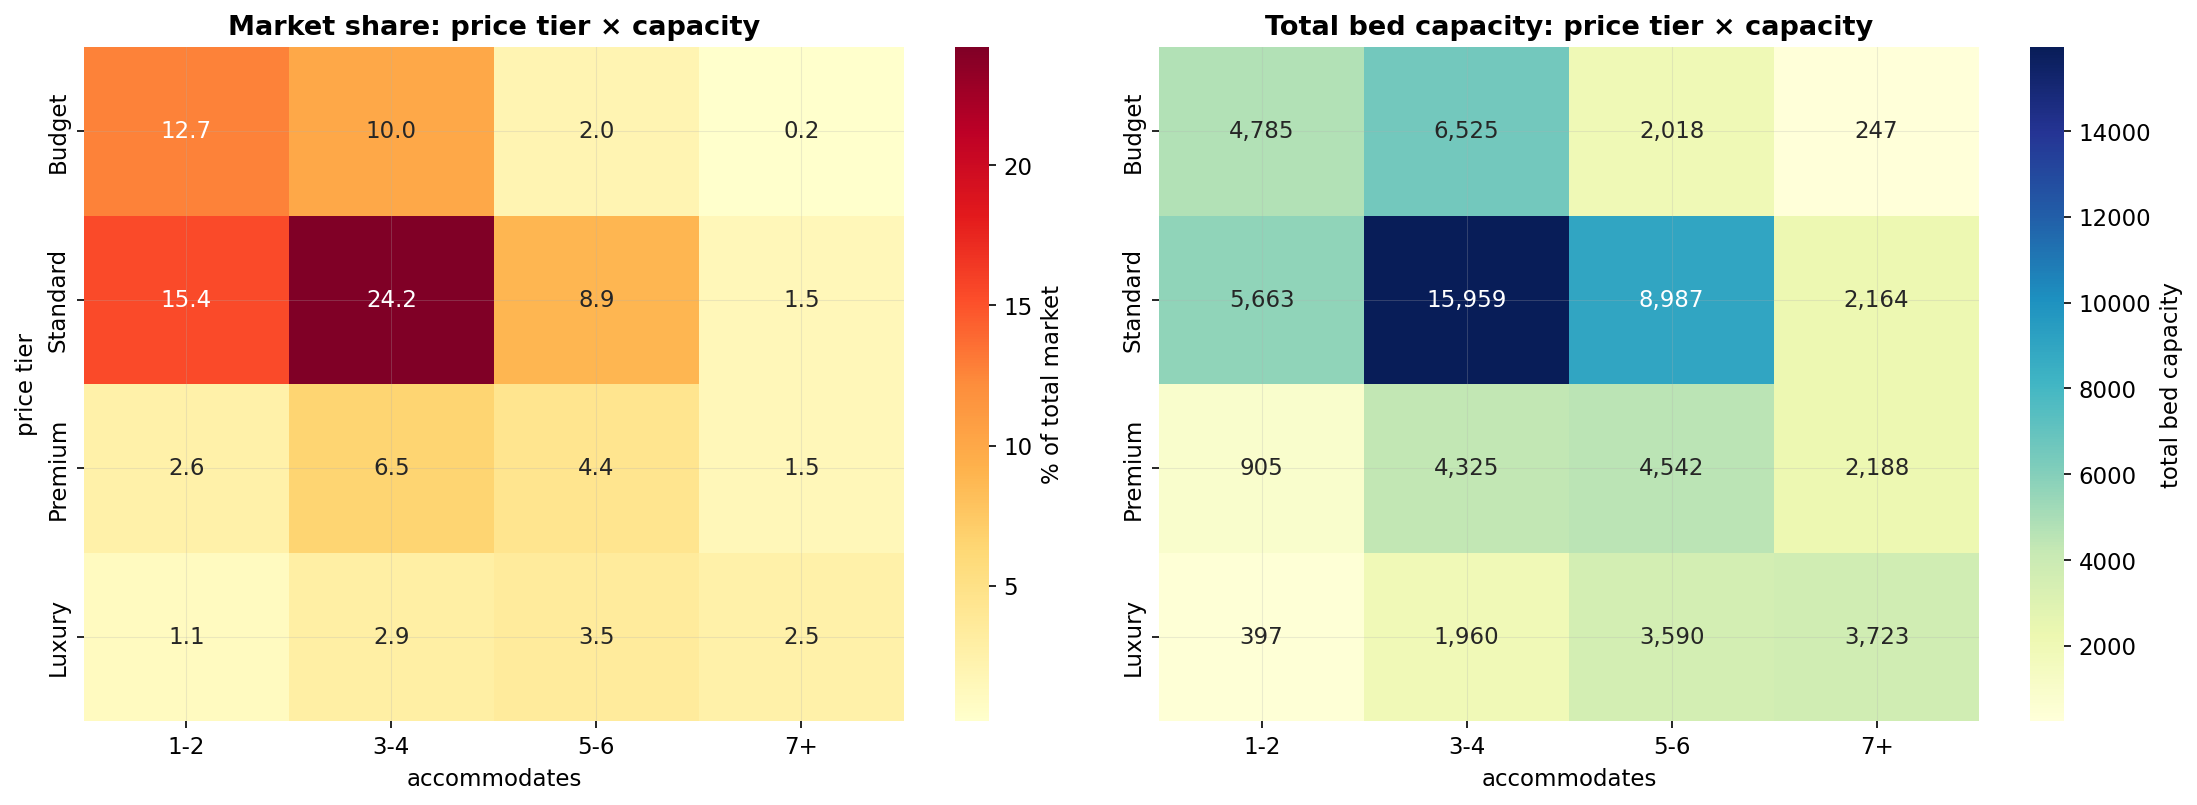

In [28]:
def bin_accommodates(a):
    if pd.isna(a): return np.nan
    if a <= 2: return '1-2'
    if a <= 4: return '3-4'
    if a <= 6: return '5-6'
    return '7+'

listings['accommodates_bin'] = listings['accommodates'].apply(bin_accommodates)
ACC_BINS = ['1-2', '3-4', '5-6', '7+']

matrix_data = listings.dropna(subset=['price_tier', 'accommodates_bin', 'beds_restored'])
pct_matrix = pd.crosstab(matrix_data['price_tier'], matrix_data['accommodates_bin'], normalize='all').mul(100).reindex(index=TIER_NAMES, columns=ACC_BINS)
beds_matrix = matrix_data.pivot_table(index='price_tier', columns='accommodates_bin', values='beds_restored', aggfunc='sum').reindex(index=TIER_NAMES, columns=ACC_BINS)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
sns.heatmap(pct_matrix, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': '% of total market'}, ax=axes[0])
axes[0].set_title('Market share: price tier × capacity')
axes[0].set_xlabel('accommodates'); axes[0].set_ylabel('price tier')

sns.heatmap(beds_matrix, annot=True, fmt=',.0f', cmap='YlGnBu', cbar_kws={'label': 'total bed capacity'}, ax=axes[1])
axes[1].set_title('Total bed capacity: price tier × capacity')
axes[1].set_xlabel('accommodates'); axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

The single densest cell on the entire market Standard price × 3-4 guests (24.2% of all listings) confirms this is the market's true center of gravity. Reading the two matrices together reveals a subtlety the left matrix alone hides: Standard/3-4 also dominates total bed volume (15,959 beds, more than double any other cell), meaning this segment isn't just numerous, it's structurally the market's backbone in terms of actual sleeping capacity supplied to guests. Luxury listings are thin in count but skew toward larger units. The Luxury/7+ cell holds more total beds (3,723) than three of its four Luxury row-mates combined, suggesting high-end listings compete less on quantity and more on hosting larger groups at a premium.

### 2.9 Market Overview Summary

Rome's Airbnb market has a clear, consistent shape running through every angle examined here. It's dominated by whole-unit rentals sized for couples and small families, priced in a right-skewed but genuinely log-normal distribution with half the market sitting in a €93-190 Standard band. The single most common configuration, Standard-priced, 3-4-guest units, isn't just the largest listing count but also the backbone of total sleeping capacity supplied.

Two structural patterns matter directly for what comes next. First, price doesn't scale linearly with capacity: solo travelers pay roughly double the per-person rate of a group of four, meaning group size is a real economic axis, not just a size detail. Second, bed capacity is only mildly concentrated, meaning this is a market of broadly similar-sized units, not one split between many tiny listings and a few large complexes, so extreme capacity outliers are unlikely to define a cluster on their own.

Luxury listings are a genuine minority by count, but skew toward larger units, competing on group size and premium positioning rather than volume.